# Philippine LFS Data Pipeline — Employee Stagnation

Builds a clean, analysis-ready dataset from 48 monthly PSA Labour Force Survey files (Jan 2021 – Dec 2024).

**Pipeline stages:**
1. Load & harmonize all 48 monthly CSVs across 3 schema versions
2. Filter to employed working-age respondents
3. Construct `is_stagnant` target via composite rule (no leakage)
4. Merge year-level GDP per person employed (World Bank / Our World in Data)
5. Engineer features: education level, occupation major group, industry sector
6. Impute missing values
7. Report class distribution; save processed dataset

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

BASE = os.path.join(os.path.dirname(os.getcwd()), 'ph-lfs-stagnation - Copy - Copy - Copy')
# If running from inside notebooks/ folder, go one level up
if not os.path.exists(os.path.join(BASE, 'data')):
    BASE = os.path.dirname(os.getcwd())
if not os.path.exists(os.path.join(BASE, 'data')):
    BASE = os.getcwd()  # fallback: running from project root

DATA_DIR = os.path.join(BASE, 'data', 'PHL-PSA-LFS-2021-2024-PUF')
GDP_PATH = os.path.join(BASE, 'data', 'gdp-per-person-employed-constant-ppp',
                        'gdp-per-person-employed-constant-ppp.csv')
OUT_DIR  = os.path.join(BASE, 'data')

print('BASE:', BASE)
print('DATA_DIR exists:', os.path.exists(DATA_DIR))

BASE: c:\Users\clyde\Desktop\ph-lfs-stagnation - Copy - Copy - Copy
DATA_DIR exists: True


## 1. Schema Harmonisation

Three survey schemas span the 2021-2024 data:

| Schema | Months | Key difference |
|--------|--------|----------------|
| A | Jan–Jul 2021 | Standard PSA LFS columns |
| B | Aug–Dec 2021 | Re-numbered HHMEM format (questionnaire redesign) |
| C | 2022–2024 | Standard columns + extra fields (arrangement, province, ethnicity) |

We rename each to a unified column set, keeping only the variables needed for target construction and prediction.

In [2]:
# ------------------------------------------------------------------
# Unified column sets per schema
# Keys = original column name, Values = canonical name
# ------------------------------------------------------------------

# Schema A: Jan-Jul 2021
SCHEMA_A = {
    'PUFREG':        'region',
    'PUFURB2015':    'urban_rural',
    'PUFSVYMO':      'survey_month',
    'PUFSVYYR':      'survey_year',
    'PUFHHSIZE':     'hh_size',
    'PUFC01_LNO':    'line_no',
    'PUFC03_REL':    'relationship',
    'PUFC04_SEX':    'sex',
    'PUFC05_AGE':    'age',
    'PUFC06_MSTAT':  'marital_status',
    'PUFC07_GRADE':  'education_grade',
    'PUFC10_CONWR':  'currently_working',
    'PUFC11_WORK':   'worked_last_week',
    'PUFC14_PROCC':  'occupation_code',
    'PUFC16_PKB':    'industry_code',
    'PUFC17_NATEM':  'nature_employment',    # 1=permanent,2=temp,3=casual
    'PUFC18_PNWHRS': 'normal_hours',
    'PUFC19_PHOURS': 'actual_hours',
    'PUFC20_PWMORE': 'want_more_work',       # 1=yes (visibly underemployed)
    'PUFC23_PCLASS': 'worker_class',         # 6=unpaid family worker
    'PUFNEWEMPSTAT': 'emp_status',
}

# Schema B: Aug-Dec 2021 (HHMEM questionnaire — items renumbered)
SCHEMA_B = {
    'PUFREG':        'region',
    'PUFURB2015':    'urban_rural',
    'PUFSVYMO':      'survey_month',
    'PUFSVYYR':      'survey_year',
    'PUFHHSIZE':     'hh_size',
    'PUFC01_LNO':    'line_no',
    'PUFC03_REL':    'relationship',
    'PUFC04_SEX':    'sex',
    'PUFC05_AGE':    'age',
    'PUFC06_MSTAT':  'marital_status',
    'PUFC07_GRADE':  'education_grade',
    'PUFC08_CONWR':  'currently_working',
    'PUFC09_WORK':   'worked_last_week',
    'PUFC13_PROCC':  'occupation_code',
    'PUFC15_PKB':    'industry_code',
    'PUFC16_NATEM':  'nature_employment',
    'PUFC17_PNWHRS': 'normal_hours',
    'PUFC18_PHOURS': 'actual_hours',
    'PUFC19_PWMORE': 'want_more_work',
    'PUFC21_PCLASS': 'worker_class',
    'PUFNEWEMPSTAT': 'emp_status',
}

# Schema C: 2022-2024 (same as A + extra columns, treated identically)
SCHEMA_C = SCHEMA_A.copy()  # same rename map; extra columns just get dropped

CANONICAL_COLS = list(SCHEMA_A.values())
print('Canonical columns:', CANONICAL_COLS)

Canonical columns: ['region', 'urban_rural', 'survey_month', 'survey_year', 'hh_size', 'line_no', 'relationship', 'sex', 'age', 'marital_status', 'education_grade', 'currently_working', 'worked_last_week', 'occupation_code', 'industry_code', 'nature_employment', 'normal_hours', 'actual_hours', 'want_more_work', 'worker_class', 'emp_status']


In [3]:
def detect_schema(cols):
    """Return the correct rename map based on column fingerprint."""
    cols_upper = [c.upper() for c in cols]
    if 'PUFC09_WORK' in cols_upper:
        return SCHEMA_B
    return SCHEMA_A  # covers both A and C; extra columns are dropped


def load_harmonise(path):
    """Load one monthly CSV, normalise column names, return canonical DataFrame."""
    df = pd.read_csv(path, low_memory=False, dtype=str)
    # Strip whitespace from column names (some files have trailing spaces)
    df.columns = df.columns.str.strip().str.upper()

    schema_map = detect_schema(df.columns)

    # Keep only the columns we can rename; fill missing canonical cols with NaN
    rename_map = {k: v for k, v in schema_map.items() if k in df.columns}
    df = df.rename(columns=rename_map)

    # Ensure every canonical column exists
    for col in CANONICAL_COLS:
        if col not in df.columns:
            df[col] = np.nan

    return df[CANONICAL_COLS].copy()


# ---- Discover all 48 monthly CSVs ----
all_paths = sorted(
    set(glob.glob(os.path.join(DATA_DIR, '**', '*.csv'), recursive=True) +
        glob.glob(os.path.join(DATA_DIR, '**', '*.CSV'), recursive=True)),
    key=lambda p: p.lower()
)
print(f'Found {len(all_paths)} monthly CSV files')

Found 48 monthly CSV files


In [4]:
# ---- Load and concatenate ----
frames = []
for path in all_paths:
    fname = os.path.basename(path)
    df = load_harmonise(path)
    frames.append(df)
    print(f'  {fname}: {len(df):,} rows')

raw = pd.concat(frames, ignore_index=True)
print(f'\nTotal rows: {len(raw):,}')
print(raw.dtypes)

  LFS PUF January 2021.csv: 188,212 rows
  LFS PUF February 2021.csv: 47,930 rows
  LFS PUF March 2021.csv: 47,606 rows
  LFS PUF April 2021.csv: 188,664 rows
  LFS PUF May 2021.csv: 47,889 rows
  LFS PUF June 2021.csv: 47,749 rows
  LFS PUF July 2021.csv: 748,713 rows
  LFS PUF August 2021 - HHMEM.CSV: 47,451 rows
  LFS PUF September 2021 - HHMEM.CSV: 47,771 rows
  LFS PUF October 2021 - HHMEM.CSV: 187,848 rows
  LFS PUF November 2021 - HHMEM.CSV: 47,417 rows
  LFS PUF December 2021 - HHMEM.CSV: 47,201 rows
  LFS PUF January 2022.csv: 736,746 rows
  LFS PUF February 2022.csv: 45,889 rows
  LFS PUF March 2022.csv: 46,154 rows
  LFS PUF April 2022.csv: 184,237 rows
  LFS PUF May 2022.csv: 46,264 rows
  LFS PUF June 2022.csv: 45,894 rows
  LFS PUF July 2022.CSV: 183,856 rows
  LFS PUF August 2022.CSV: 45,054 rows
  LFS PUF September 2022.CSV: 46,261 rows
  LFS PUF October 2022.CSV: 183,602 rows
  LFS PUF November 2022.CSV: 45,561 rows
  LFS PUF December 2022.CSV: 45,687 rows
  LFS PUF Ja

## 2. Type Coercion & Cleaning

All values loaded as strings (to avoid silent numeric truncation of coded values). Now we cast columns to appropriate types.

In [5]:
def to_int_nullable(series):
    """Strip whitespace, coerce to numeric, return as Int64 (nullable int)."""
    return pd.to_numeric(series.astype(str).str.strip(), errors='coerce').astype('Int64')


def to_str_stripped(series):
    """Strip whitespace; blank → NaN."""
    s = series.astype(str).str.strip()
    s = s.replace({'': np.nan, 'nan': np.nan, 'NaN': np.nan})
    return s


# Numeric columns
INT_COLS = ['survey_month', 'survey_year', 'region', 'hh_size', 'line_no',
            'relationship', 'sex', 'age', 'marital_status',
            'urban_rural', 'currently_working', 'worked_last_week',
            'normal_hours', 'actual_hours', 'want_more_work',
            'worker_class', 'nature_employment', 'emp_status']

for col in INT_COLS:
    raw[col] = to_int_nullable(raw[col])

# String-coded columns (occupation and industry use 2-char codes; grade is 5-char)
STR_COLS = ['education_grade', 'occupation_code', 'industry_code']
for col in STR_COLS:
    raw[col] = to_str_stripped(raw[col])

print(raw.dtypes)
print('\nNull counts:')
print(raw.isnull().sum())

region               Int64
urban_rural          Int64
survey_month         Int64
survey_year          Int64
hh_size              Int64
line_no              Int64
relationship         Int64
sex                  Int64
age                  Int64
marital_status       Int64
education_grade        str
currently_working    Int64
worked_last_week     Int64
occupation_code        str
industry_code          str
nature_employment    Int64
normal_hours         Int64
actual_hours         Int64
want_more_work       Int64
worker_class         Int64
emp_status           Int64
dtype: object

Null counts:
region                348457
urban_rural          1935474
survey_month               0
survey_year                0
hh_size                    0
line_no                   26
relationship               0
sex                        0
age                        0
marital_status        448570
education_grade       451664
currently_working    1786033
worked_last_week      544726
occupation_code      3790020

## 3. Filter to Employed Working-Age Population

`emp_status == 1` captures all employed persons (those who worked ≥1 hour AND those temporarily absent from a job) as defined by PSA.

Age filter ≥ 15 per PSA's working-age population definition.

Rows without an employment status (children, non-interviewed) are excluded.

In [6]:
print('emp_status distribution:')
print(raw['emp_status'].value_counts(dropna=False).sort_index())
# 1=Employed, 2=Unemployed, 3=Not in labor force, NaN=not applicable (child)

employed = raw[(raw['emp_status'] == 1) & (raw['age'] >= 15)].copy()
print(f'\nEmployed working-age: {len(employed):,} rows  ({len(employed)/len(raw)*100:.1f}% of total)')

emp_status distribution:
emp_status
1       2740496
2        149315
3       1785149
<NA>    1879095
Name: count, dtype: Int64

Employed working-age: 2,740,496 rows  (41.8% of total)


## 4. Construct `is_stagnant` Target Variable

### Definition

Employee stagnation = being stuck in a low-quality labour market position with insufficient upward mobility. No direct survey question exists, so we operationalise it from three PSA-defined indicators. A worker is **stagnant** if ≥ 2 of the following 3 criteria are satisfied:

| Criterion | Variable | Logic |
|-----------|----------|-------|
| **C1 – Visible underemployment** | `want_more_work` | = 1 (wants additional work or hours) |
| **C2 – Precarious job** | `nature_employment`, `worker_class` | nature ∈ {2=temporary, 3=casual/seasonal} OR class = 6 (unpaid family worker) |
| **C3 – Education-occupation mismatch** | `education_grade`, `occupation_code` | College-educated (grade level ≥ 6) working in elementary occupations (PSOC major group = 9) |

### Leakage Prevention

`want_more_work`, `nature_employment`, and `worker_class` are used **only** to construct the target. They are dropped from the feature matrix before modelling. `education_grade` and `occupation_code` are also used in C3 but are legitimate predictors on their own (education predicts stagnation risk independently of the mismatch rule). They are retained as features in their encoded forms.

### Why 2-of-3 composite?

Any single indicator has blind spots:
- Underemployment alone can be voluntary or seasonal
- Temporary contracts are not always stagnation (probationary periods, project-based)
- Mismatch is measured at a point in time and may reflect a transition

Requiring 2 of 3 signals to co-occur substantially reduces false positives and captures the multi-dimensional nature of genuine stagnation.

In [7]:
# ---- Encode education level (first character of the 5-digit grade code) ----
# PSA grade code structure: first digit = education system level
#   0=no grade, 1=elementary, 2=old high school, 3=junior HS (K-12),
#   4=senior HS (K-12), 5=vocational/technical, 6=college, 7=post-graduate
employed['education_level'] = (
    employed['education_grade']
    .astype(str)
    .str.strip()
    .str[0]                              # take first character
    .replace({'n': np.nan, 'N': np.nan}) # 'nan' strings
    .pipe(pd.to_numeric, errors='coerce')
    .astype('Int64')
)

# ---- Encode occupation major group (first digit of 2-char PSOC code) ----
# PSOC major groups: 1=Managers, 2=Professionals, 3=Technicians,
# 4=Clerical, 5=Service/Sales, 6=Agri/Fishery skilled, 7=Craft,
# 8=Plant operators, 9=Elementary occupations
employed['occupation_major'] = (
    employed['occupation_code']
    .astype(str)
    .str.strip()
    .str[0]
    .replace({'': np.nan, 'n': np.nan, 'N': np.nan})
    .pipe(pd.to_numeric, errors='coerce')
    .astype('Int64')
)

print('education_level distribution:')
print(employed['education_level'].value_counts(dropna=False).sort_index())
print('\noccupation_major distribution:')
print(employed['occupation_major'].value_counts(dropna=False).sort_index())

education_level distribution:
education_level
0      42210
1     665119
2    1066858
3      84345
4      31585
5      65693
6     762137
7      17998
8       4551
Name: count, dtype: Int64

occupation_major distribution:
occupation_major
0      6291
1    145502
2    146671
3    106193
4    178636
5    593954
6    406346
7    184234
8    196780
9    775889
Name: count, dtype: Int64


In [8]:
# ---- Three stagnation criteria ----
# Treat NaN as 0 (benefit of the doubt — unknown ≠ stagnant)

c1 = (employed['want_more_work'] == 1).fillna(False).astype(int)

c2 = (
    employed['nature_employment'].isin([2, 3]).fillna(False) |
    (employed['worker_class'] == 6).fillna(False)
).astype(int)

c3 = (
    (employed['education_level'] >= 6).fillna(False) &
    (employed['occupation_major'] == 9).fillna(False)
).astype(int)

stagnation_score = c1 + c2 + c3
employed['is_stagnant'] = (stagnation_score >= 2).astype(int)

print('Stagnation score distribution:')
print(stagnation_score.value_counts().sort_index())
print(f'\nis_stagnant = 1: {employed["is_stagnant"].sum():,}  ({employed["is_stagnant"].mean()*100:.1f}%)')
print(f'is_stagnant = 0: {(employed["is_stagnant"]==0).sum():,}  ({(1-employed["is_stagnant"].mean())*100:.1f}%)')

# Per-year stagnation rate
print('\nStagnation rate by year:')
print(employed.groupby('survey_year')['is_stagnant'].mean().mul(100).round(2))

Stagnation score distribution:
0    1609873
1     909229
2     213094
3       8300
Name: count, dtype: int64

is_stagnant = 1: 221,394  (8.1%)
is_stagnant = 0: 2,519,102  (91.9%)

Stagnation rate by year:
survey_year
2021   9.5000
2022   8.0800
2023   7.8100
2024   6.9500
Name: is_stagnant, dtype: float64


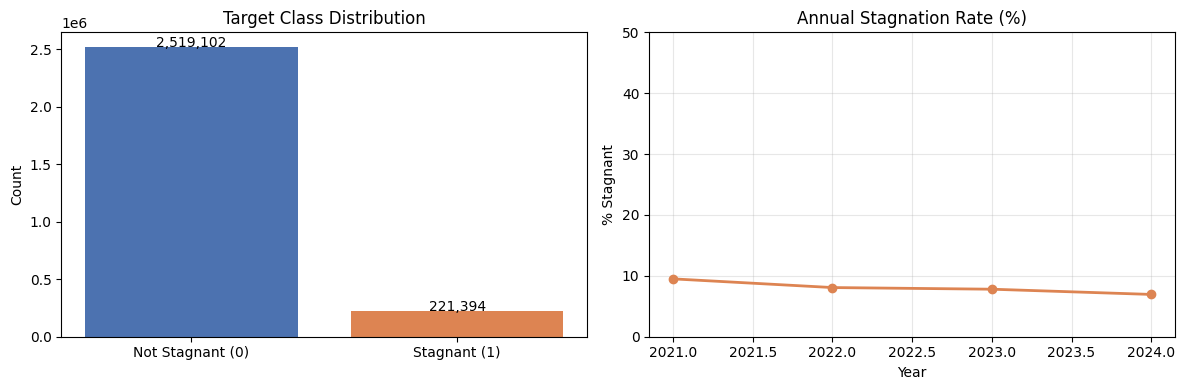

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall class distribution
class_counts = employed['is_stagnant'].value_counts().sort_index()
axes[0].bar(['Not Stagnant (0)', 'Stagnant (1)'], class_counts.values,
            color=['#4C72B0', '#DD8452'])
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Stagnation rate by year
yr_rate = employed.groupby('survey_year')['is_stagnant'].mean().mul(100)
axes[1].plot(yr_rate.index, yr_rate.values, marker='o', linewidth=2, color='#DD8452')
axes[1].set_title('Annual Stagnation Rate (%)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% Stagnant')
axes[1].set_ylim(0, 50)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'stagnation_class_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

## 5. Merge GDP per Person Employed

Year-level macro context from the World Bank (constant 2021 PPP dollars). Joined on `survey_year`.

In [10]:
gdp = pd.read_csv(GDP_PATH)
gdp_phl = (
    gdp[gdp['Code'] == 'PHL']
    [['Year', 'GDP per person employed (constant 2021 PPP $)']]
    .rename(columns={
        'Year': 'survey_year',
        'GDP per person employed (constant 2021 PPP $)': 'gdp_per_employed'
    })
)
print(gdp_phl[gdp_phl['survey_year'].between(2021, 2024)])

employed = employed.merge(gdp_phl, on='survey_year', how='left')
print(f'\nGDP merge null count: {employed["gdp_per_employed"].isna().sum()}')

      survey_year  gdp_per_employed
4575         2021        23200.7150
4576         2022        22362.2710
4577         2023        23081.7190
4578         2024        23954.4880

GDP merge null count: 0


## 6. Feature Engineering

Features selected must have no causal overlap with the stagnation criteria:
- `want_more_work`, `nature_employment`, `worker_class` → **dropped** (used in target)
- `occupation_code`, `industry_code` → compressed to major group (1–2 digit)
- `education_grade` → compressed to `education_level` (0–7 ordinal)

`survey_month` is retained as a cyclical feature to capture seasonality (agriculture peaks, holiday hiring, etc.).

In [11]:
# ---- Industry: extract 2-digit PSIC major division ----
# Industry codes are stored as 2-char strings (e.g. '01', '47', '84')
employed['industry_major'] = (
    pd.to_numeric(employed['industry_code'].astype(str).str.strip(), errors='coerce')
    .astype('Int64')
)

# Bin into broad PSIC sectors
def psic_sector(code):
    if pd.isna(code):   return 0   # unknown
    c = int(code)
    if c <= 3:          return 1   # Agriculture, forestry, fishing
    if c <= 9:          return 2   # Mining & quarrying
    if c <= 33:         return 3   # Manufacturing
    if c <= 43:         return 4   # Construction, utilities
    if c <= 47:         return 5   # Wholesale & retail trade
    if c <= 56:         return 6   # Transport, accommodation, food
    if c <= 66:         return 7   # ICT, financial services
    if c <= 82:         return 8   # Real estate, professional, admin
    if c <= 88:         return 9   # Public admin, education, health
    return 10                      # Other services

employed['industry_sector'] = employed['industry_major'].apply(psic_sector)

# ---- Cyclical encoding for survey_month (sin/cos) ----
employed['month_sin'] = np.sin(2 * np.pi * employed['survey_month'].astype(float) / 12)
employed['month_cos'] = np.cos(2 * np.pi * employed['survey_month'].astype(float) / 12)

print('Industry sector distribution:')
print(employed['industry_sector'].value_counts().sort_index())

Industry sector distribution:
industry_sector
1     723535
2      16281
3     176713
4     262803
5     557857
6     291967
7      59105
8     151009
9     321832
10    179394
Name: count, dtype: int64


In [12]:
# ---- Define the final feature set ----
# TARGET-DEFINING cols excluded: want_more_work, nature_employment, worker_class
# Raw string cols excluded: education_grade, occupation_code, industry_code (replaced by encoded)
# Survey admin cols excluded: survey_month (replaced by sin/cos), line_no, relationship
# Continuous cols: age, hh_size, normal_hours, actual_hours, gdp_per_employed

FEATURE_COLS = [
    # demographics
    'age',
    'sex',             # 1=male, 2=female
    'marital_status',  # 1=single,2=married,3=widowed,4=divorced,5=common-law
    # geography
    'region',          # 1-17 (NCR to ARMM/BARMM)
    'urban_rural',     # 1=urban, 2=rural  (NaN in 2024 — will impute)
    # household
    'hh_size',
    # human capital
    'education_level', # 0-7 ordinal
    # labour market position
    'occupation_major',# 1-9 PSOC major group
    'industry_sector', # 1-10 broad PSIC sector
    # work intensity
    'normal_hours',
    'actual_hours',
    # seasonality
    'month_sin',
    'month_cos',
    # macro
    'gdp_per_employed',
]

TARGET_COL = 'is_stagnant'

model_df = employed[FEATURE_COLS + [TARGET_COL, 'survey_year', 'survey_month']].copy()
print(f'Model dataset shape: {model_df.shape}')
print(model_df[FEATURE_COLS].isnull().sum().sort_values(ascending=False))

Model dataset shape: (2740496, 17)
urban_rural         838086
region              157634
sex                      0
age                      0
marital_status           0
hh_size                  0
education_level          0
occupation_major         0
industry_sector          0
normal_hours             0
actual_hours             0
month_sin                0
month_cos                0
gdp_per_employed         0
dtype: int64


## 7. Imputation

**Strategy:**
- `urban_rural`: missing for all 2024 respondents (column removed from survey). Imputed with **mode** of the training partition (not global mode, to prevent any future leakage).
- `occupation_major`, `industry_sector`: missing for respondents whose job information was not captured (e.g., unpaid workers, certain self-employed). Imputed with **0** ("unknown" sentinel) — this preserves the information that occupation is unreported.
- `normal_hours`, `actual_hours`: missing for workers temporarily absent. Imputed with **median** per occupation_major group to respect job-type differences.
- `education_level`: rare missingness. Imputed with **median**.
- All other numeric: **median** imputation.

In [13]:
from sklearn.model_selection import train_test_split

# ---- Train/test split BEFORE imputation to prevent leakage ----
# Temporal split: train on 2021-2023, test on 2024
# Rationale: more realistic than random split; simulates predicting future stagnation
train_mask = model_df['survey_year'] < 2024
test_mask  = model_df['survey_year'] == 2024

X_train = model_df.loc[train_mask, FEATURE_COLS].copy()
y_train = model_df.loc[train_mask, TARGET_COL].copy()
X_test  = model_df.loc[test_mask,  FEATURE_COLS].copy()
y_test  = model_df.loc[test_mask,  TARGET_COL].copy()

print(f'Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')
print(f'Train stagnation rate: {y_train.mean()*100:.2f}%')
print(f'Test  stagnation rate: {y_test.mean()*100:.2f}%')

Train: 2,060,789 rows | Test: 679,707 rows
Train stagnation rate: 8.45%
Test  stagnation rate: 6.95%


In [14]:
# ---- Fit imputation statistics on TRAIN only ----

# Categorical / ordinal columns: mode imputation
FILL_MODE = ['urban_rural', 'marital_status', 'region', 'sex',
             'education_level', 'occupation_major', 'industry_sector']
# Continuous columns: median imputation
FILL_MEDIAN = ['age', 'hh_size', 'normal_hours', 'actual_hours', 'gdp_per_employed']

fill_values = {}
for col in FILL_MODE:
    mode_val = X_train[col].mode(dropna=True)
    fill_values[col] = int(mode_val.iloc[0]) if len(mode_val) > 0 else 0

for col in FILL_MEDIAN:
    fill_values[col] = float(X_train[col].median())

# Cyclical month features derived from integer month — no missing expected
fill_values['month_sin'] = 0.0
fill_values['month_cos'] = 1.0

print('Imputation fill values:')
for k, v in fill_values.items():
    print(f'  {k}: {v}')

Imputation fill values:
  urban_rural: 2
  marital_status: 2
  region: 13
  sex: 1
  education_level: 2
  occupation_major: 9
  industry_sector: 1
  age: 40.0
  hh_size: 5.0
  normal_hours: 8.0
  actual_hours: 40.0
  gdp_per_employed: 23081.719
  month_sin: 0.0
  month_cos: 1.0


In [15]:
# ---- Apply imputation ----
def impute(df, fill_values):
    df = df.copy()
    for col, val in fill_values.items():
        if col in df.columns:
            df[col] = df[col].fillna(val)
    return df

X_train = impute(X_train, fill_values)
X_test  = impute(X_test,  fill_values)

# Cast all features to float64 for sklearn
X_train = X_train.astype(float)
X_test  = X_test.astype(float)

print('Post-imputation null counts (train):')
print(X_train.isnull().sum().sum())
print('Post-imputation null counts (test):')
print(X_test.isnull().sum().sum())
print(f'\nX_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')

Post-imputation null counts (train):
0
Post-imputation null counts (test):
0

X_train shape: (2060789, 14)
X_test  shape: (679707, 14)


## 8. Class Imbalance Analysis

We use `class_weight='balanced'` in the logistic regression rather than SMOTE or random over/undersampling. At this data scale (~1M+ rows), SMOTE is computationally prohibitive and random undersampling discards real signal. The `class_weight='balanced'` approach re-weights the loss function to give proportionally more penalty for misclassifying the minority class — mathematically equivalent to oversampling the minority class, without modifying the data distribution.

In [16]:
n_pos = y_train.sum()
n_neg = (y_train == 0).sum()
ratio = n_neg / n_pos

print(f'Train class distribution:')
print(f'  Stagnant (1):     {n_pos:>10,}  ({n_pos/(n_pos+n_neg)*100:.1f}%)')
print(f'  Not stagnant (0): {n_neg:>10,}  ({n_neg/(n_pos+n_neg)*100:.1f}%)')
print(f'  Imbalance ratio:  {ratio:.2f}:1')
print(f'\nclass_weight="balanced" will up-weight stagnant class by factor {ratio:.2f}')

Train class distribution:
  Stagnant (1):        174,176  (8.5%)
  Not stagnant (0):  1,886,613  (91.5%)
  Imbalance ratio:  10.83:1

class_weight="balanced" will up-weight stagnant class by factor 10.83


## 9. Save Processed Data

In [17]:
import joblib

# Save train/test sets
X_train.to_csv(os.path.join(OUT_DIR, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(OUT_DIR, 'X_test.csv'),  index=False)
y_train.to_csv(os.path.join(OUT_DIR, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(OUT_DIR, 'y_test.csv'),  index=False)

# Save imputation fill values for reproducibility
joblib.dump(fill_values, os.path.join(OUT_DIR, 'imputation_fill_values.pkl'))

# Save full processed employed dataset (before split) for EDA
employed.to_csv(os.path.join(OUT_DIR, 'employed_processed.csv'), index=False)

print('Saved:')
for f in ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv',
          'imputation_fill_values.pkl', 'employed_processed.csv']:
    fp = os.path.join(OUT_DIR, f)
    size_mb = os.path.getsize(fp) / 1e6 if os.path.exists(fp) else 0
    print(f'  {f}: {size_mb:.1f} MB')

Saved:
  X_train.csv: 197.2 MB
  X_test.csv: 65.0 MB
  y_train.csv: 6.2 MB
  y_test.csv: 2.0 MB
  imputation_fill_values.pkl: 0.0 MB
  employed_processed.csv: 310.2 MB


## 10. Quick EDA on Processed Data

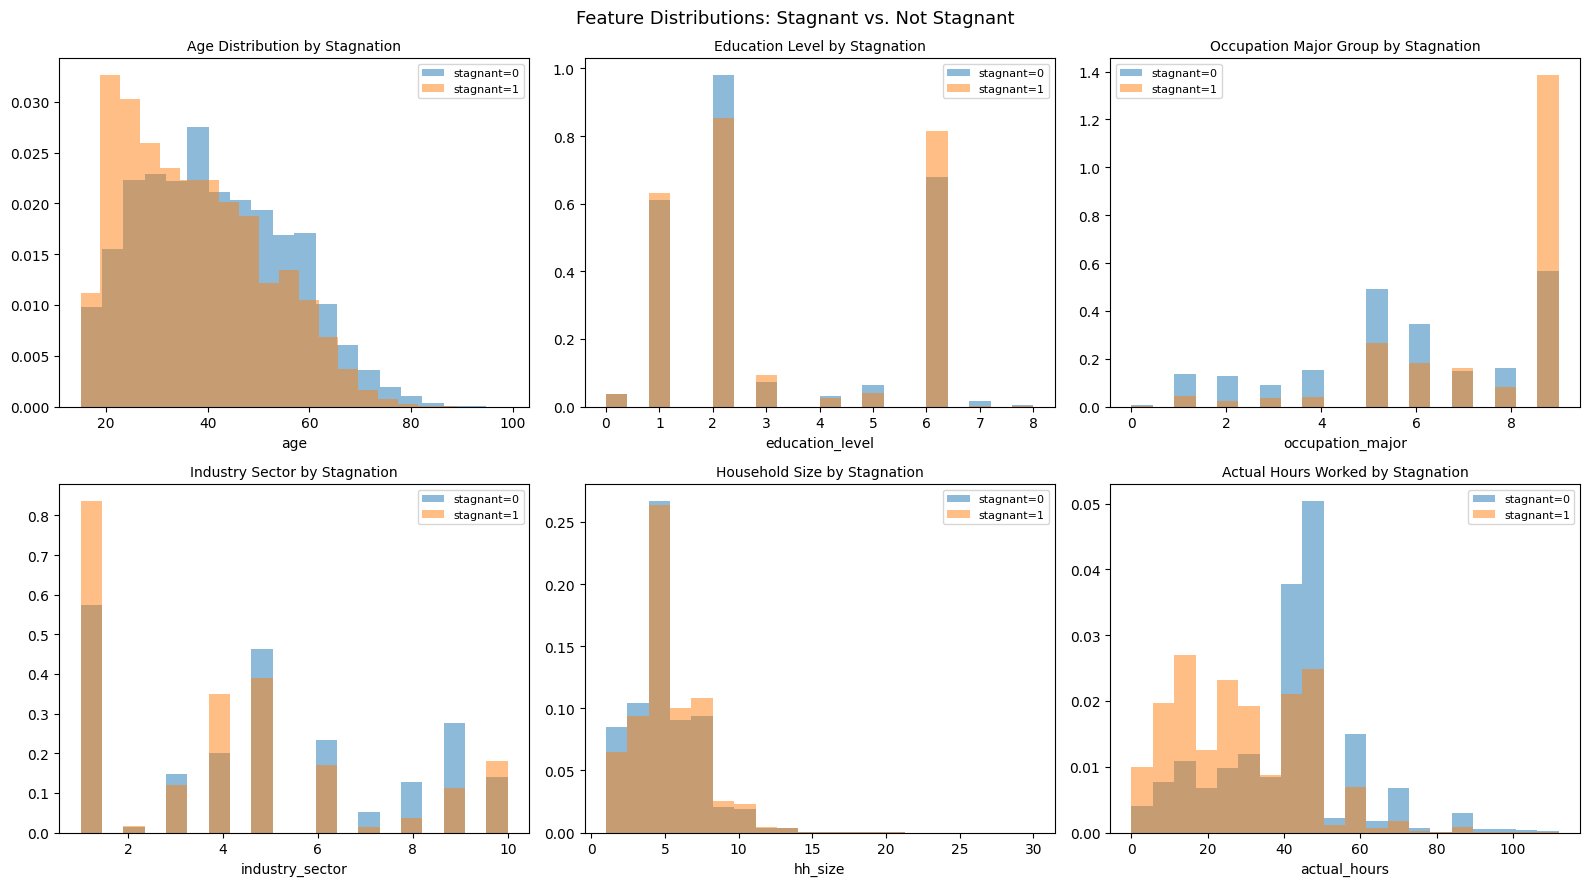

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

plot_specs = [
    ('age',             'Age Distribution by Stagnation'),
    ('education_level', 'Education Level by Stagnation'),
    ('occupation_major','Occupation Major Group by Stagnation'),
    ('industry_sector', 'Industry Sector by Stagnation'),
    ('hh_size',         'Household Size by Stagnation'),
    ('actual_hours',    'Actual Hours Worked by Stagnation'),
]

plot_df = X_train.copy()
plot_df['is_stagnant'] = y_train.values

for ax, (col, title) in zip(axes, plot_specs):
    for label, grp in plot_df.groupby('is_stagnant'):
        ax.hist(grp[col].dropna(), bins=20, alpha=0.5,
                label=f'stagnant={label}', density=True)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Stagnant vs. Not Stagnant', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'feature_distributions.png'), dpi=120, bbox_inches='tight')
plt.show()

In [19]:
print('Pipeline complete.')
print(f'  Training samples : {len(X_train):,}')
print(f'  Test samples     : {len(X_test):,}')
print(f'  Features         : {len(FEATURE_COLS)}')
print(f'  Stagnation rate (train): {y_train.mean()*100:.2f}%')
print(f'  Stagnation rate (test) : {y_test.mean()*100:.2f}%')

Pipeline complete.
  Training samples : 2,060,789
  Test samples     : 679,707
  Features         : 14
  Stagnation rate (train): 8.45%
  Stagnation rate (test) : 6.95%
